In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
tommy_award_player = pd.read_csv(csv_path)

rng = np.random.RandomState(2)
indices = np.arange(len(tommy_award_player))
rng.shuffle(indices)

tommy_award_player.head()

,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [7]:
target_col = "y"  # binary winner label: 1 = winner, 0 = not winner

# Use only numeric feature columns so sklearn models can consume X directly.
feature_df = tommy_award_player.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")

# LabelSpreading cannot handle NaN/inf values, so we impute missing feature values.
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True)).fillna(0)

y_all = tommy_award_player[target_col].astype(int).to_numpy()

sample_size = min(340, len(tommy_award_player))
X = feature_df.to_numpy()[indices[:sample_size]]
y = y_all[indices[:sample_size]]

n_total_samples = len(y)
n_labeled_points = min(40, n_total_samples)

indices = np.arange(n_total_samples)
unlabeled_set = indices[n_labeled_points:]

In [8]:
y_train = np.copy(y)
y_train[unlabeled_set] = -1

In [9]:
from sklearn.metrics import classification_report
from sklearn.semi_supervised import LabelSpreading

lp_model = LabelSpreading(gamma=0.25, max_iter=20)
lp_model.fit(X, y_train)
predicted_labels = lp_model.transduction_[unlabeled_set]
true_labels = y[unlabeled_set]

print(
    "Label Spreading model: %d labeled & %d unlabeled points (%d total)"
    % (n_labeled_points, n_total_samples - n_labeled_points, n_total_samples)
)

Label Spreading model: 40 labeled & 300 unlabeled points (340 total)


In [10]:
print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       273
           1       0.00      0.00      0.00        27

    accuracy                           0.91       300
   macro avg       0.46      0.50      0.48       300
weighted avg       0.83      0.91      0.87       300



/Users/teddytaussig/anaconda3/envs/COM328/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/teddytaussig/anaconda3/envs/COM328/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/teddytaussig/anaconda3/envs/COM328/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

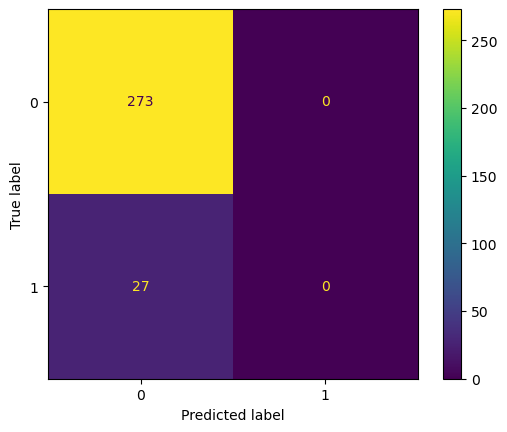

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_labels, predicted_labels, labels=lp_model.classes_
)

In [12]:
from scipy import stats

pred_entropies = stats.distributions.entropy(lp_model.label_distributions_.T)